In [2]:
from pathlib import Path
from textalloc import allocate
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [3]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))
# input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_population_bins_beta_zero_pop_0.25.yml").read_text(encoding="utf-8"))


population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]
public_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][0]
private_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][1]

print(f"Population scale: {population_scale_from_input_yml}")
print(f"Starting date: {starting_date}")
print(f"Birth rate: {birth_rate_from_config}")
print(f"Public percentage: {public_pct}")
print(f"Private percentage: {private_pct}")

# 1) Use the original dict
country_dict = {
    "population_scale": population_scale_from_input_yml,
    }
country_json = json.dumps(country_dict, ensure_ascii=False)
# 3) Attribute-style access (SimpleNamespace)
from types import SimpleNamespace
country = json.loads(country_json, object_hook=lambda d: SimpleNamespace(**d))

exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print("\ndata_path:", data_path)
print("output_path:", output_path)
print("analysis_path:", analysis_path)

Population scale: 0.25
Starting date: 2011/1/1
Birth rate: 0.0335
Public percentage: 0.445
Private percentage: 0.555

data_path: DATA
output_path: validation_runs/validation_4_0.25_population_scale_one_pattern_20_replicates/output
analysis_path: validation_runs/validation_4_0.25_population_scale_one_pattern_20_replicates/analysis


## PfPR

In [4]:
output_path_obj = Path(output_path)
if not output_path_obj.exists() or not output_path_obj.is_dir():
    raise NotADirectoryError(f"Path {output_path} is not a valid directory.")
db_files = list(output_path_obj.glob("*.db"))
if len(db_files) == 0:
    raise FileNotFoundError(f"No .db files found in directory {output_path}.")

agg_population = pd.DataFrame(columns=["monthly_data_id", "unit_id", "population"])
agg_treatment = pd.DataFrame(columns=["monthly_data_id", "unit_id", "treatments"])
agg_clinical_episodes = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes"])
agg_prevalence_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_2to10"])
agg_clinical_episodes_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"])
agg_prevalence_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_under5"])
agg_clinical_episodes_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_under5"])

rep = 0
for file in output_path_obj.glob("*.db"):
    data = get_table(file, "monthly_site_data_district")
    clinical_episodes_2_to_10 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].copy()
    clinical_episodes_2_to_10["clinical_episodes_2_to_10"] = clinical_episodes_2_to_10[
        [
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].sum(axis=1)
    clinical_episodes_under_5 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].copy()
    clinical_episodes_under_5["clinical_episodes_under5"] = clinical_episodes_under_5[
        [
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].sum(axis=1)
    
    # Add a column to the agg_* data frames from data
    try:
        agg_population = agg_population.merge(
            data[["monthly_data_id", "unit_id", "population"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_treatment = agg_treatment.merge(
            data[["monthly_data_id", "unit_id", "treatments"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes = agg_clinical_episodes.merge(
            data[["monthly_data_id", "unit_id", "clinical_episodes"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_2_to_10 = agg_prevalence_2_to_10.merge(
            data[["monthly_data_id", "unit_id", "pfpr_2to10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        
        agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.merge(
            clinical_episodes_2_to_10[["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_under_5 = agg_prevalence_under_5.merge(
            data[["monthly_data_id", "unit_id", "pfpr_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.merge(
            clinical_episodes_under_5[["monthly_data_id", "unit_id", "clinical_episodes_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
    except Exception as e:
        error(f"Error processing replicate {rep}: {e}")
    rep += 1
    
agg_population = agg_population.drop(columns=["population"])
agg_treatment = agg_treatment.drop(columns=["treatments"])
agg_clinical_episodes = agg_clinical_episodes.drop(columns=["clinical_episodes"])
agg_prevalence_2_to_10 = agg_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.drop(columns=["clinical_episodes_2_to_10"])
agg_prevalence_under_5 = agg_prevalence_under_5.drop(columns=["pfpr_under5"])
agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.drop(columns=["clinical_episodes_under5"])

agg_prevalence_2_to_10.to_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv", index=False)
agg_clinical_episodes_2_to_10.to_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv", index=False)
agg_prevalence_under_5.to_csv(f"{analysis_path}/agg_prevalence_under_5.csv", index=False)
agg_clinical_episodes_under_5.to_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv", index=False)
agg_population.to_csv(f"{analysis_path}/agg_population.csv", index=False)
agg_treatment.to_csv(f"{analysis_path}/agg_treatment.csv", index=False)
agg_clinical_episodes.to_csv(f"{analysis_path}/agg_clinical_episodes.csv", index=False)

In [5]:
# agg_clinical_episodes.tail(24)
agg_clinical_episodes = agg_clinical_episodes.sort_values("unit_id", ascending=False).reset_index(drop=True)
unit_id_to_inspect = 6
agg_clinical_episodes.loc[
    agg_clinical_episodes["unit_id"] == unit_id_to_inspect
].sort_values("monthly_data_id")
agg_clinical_episodes.tail(24)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
918,87,1,60572,60883,60739,60529,60751,60827,60815,60690,...,60767,60673,61012,60762,60481,60932,61115,60822,60815,60828
919,83,1,66633,67570,67207,66961,67237,67099,66911,67385,...,67000,67674,67103,66852,67252,67404,66437,66410,67120,66781
920,84,1,64662,65118,65155,64733,64988,64557,64988,65577,...,65071,65366,64925,65001,64514,65364,64540,64554,64955,64737
921,80,1,67006,67235,66794,66349,67167,66587,66183,66551,...,66881,67233,67016,66716,66369,66968,66309,66427,66337,66369
922,81,1,67049,66770,67156,67058,67328,66869,66216,67001,...,67053,67392,66868,66373,66919,67284,66716,66068,66483,66691
923,135,1,65061,65644,65615,65386,65876,66162,65443,65671,...,65610,65245,65988,65547,65383,65601,65946,65363,65631,66031
924,136,1,72188,72817,72332,73042,72046,72496,72872,72612,...,72560,72834,72585,72541,72605,72968,73232,72168,73160,72941
925,37,1,60365,60466,60866,60619,60701,60816,60805,60512,...,60892,60910,60711,60728,60952,60753,60688,60633,60959,60638
926,157,1,74828,74588,74912,74639,74426,74344,75222,74699,...,74948,74826,75178,74347,75108,74364,74623,75622,75321,74406
927,2,1,529567,530724,526295,528830,526733,526588,528443,526634,...,528557,527701,527834,527920,528814,527550,527429,529099,528668,529292


In [6]:
months = np.sort(agg_clinical_episodes["monthly_data_id"].unique())
end_month = int(months[-1]) + 1
start_month = end_month - 12

In [7]:
agg_test = pd.DataFrame(columns=["monthly_data_id", "unit_id"])

In [8]:
data_test = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes",
            "population",
            "treatments"
        ]    
    ].copy()

In [9]:
agg_test

,monthly_data_id,unit_id


In [10]:
data_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1338550,0
1,1,2,0,829974,0
2,1,3,0,680198,0
3,1,4,0,575813,0
4,1,5,0,985366,0
...,...,...,...,...,...
937,157,2,45783,1008632,22395
938,157,3,37474,851703,21318
939,157,4,31308,701320,13445
940,157,5,63004,1223622,23451


In [11]:
agg_test = agg_test.merge(
    data[["monthly_data_id", "unit_id", "clinical_episodes","population","treatments"]].copy(),
    how="outer",
    on=["monthly_data_id", "unit_id"],
    suffixes=("", f"_{validation_replicates}"),
)

In [12]:
agg_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1338550,0
1,1,2,0,829974,0
2,1,3,0,680198,0
3,1,4,0,575813,0
4,1,5,0,985366,0
...,...,...,...,...,...
937,157,2,45783,1008632,22395
938,157,3,37474,851703,21318
939,157,4,31308,701320,13445
940,157,5,63004,1223622,23451


In [13]:
agg_test_at_calib = agg_test.loc[agg_test["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()

In [14]:
g = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"]

In [15]:
for unit_id, vals in g:
    print("unit_id:", unit_id)
    print(vals)
    print()

unit_id: 1
870    73676
876    66629
882    74052
888    72244
894    74191
900    71981
906    74313
912    74598
918    72053
924    74561
930    72486
936    74406
Name: clinical_episodes, dtype: int64

unit_id: 2
871    44736
877    40376
883    45216
889    43751
895    45259
901    43593
907    45406
913    45629
919    44168
925    45806
931    44607
937    45783
Name: clinical_episodes, dtype: int64

unit_id: 3
872    36751
878    33557
884    37383
890    36266
896    36968
902    36171
908    37374
914    37126
920    35622
926    37269
932    35927
938    37474
Name: clinical_episodes, dtype: int64

unit_id: 4
873    30789
879    27919
885    30940
891    30031
897    31118
903    29942
909    31171
915    31077
921    30339
927    31088
933    30241
939    31308
Name: clinical_episodes, dtype: int64

unit_id: 5
874    62014
880    55958
886    62364
892    60012
898    62701
904    61318
910    62770
916    62413
922    60829
928    62863
934    60622
940    63004
Name: cli

In [16]:
agg_test_at_calib_mean_by_location = pd.DataFrame()
agg_test_at_calib_mean_by_location["clinical_episodes_mean"] = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"].sum()
agg_test_at_calib_mean_by_location["population_mean"] = agg_test_at_calib.copy().groupby("unit_id")["population"].mean()
agg_test_at_calib_mean_by_location["treatments_mean"] = agg_test_at_calib.copy().groupby("unit_id")["treatments"].sum()

In [17]:
agg_test_at_calib_mean_by_location

,clinical_episodes_mean,population_mean,treatments_mean
unit_id,,,
1,875190,1.671085e+06,525600
2,534330,1.001226e+06,260111
3,437888,8.447062e+05,249846
4,365963,6.961397e+05,157714
5,736868,1.214017e+06,273793
6,437954,8.136152e+05,166217


In [18]:
agg_test_at_calib_mean_by_location.sum(axis=0)

clinical_episodes_mean    3388193.00
population_mean           6240789.25
treatments_mean           1633281.00
dtype: float64

In [19]:
agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [20]:
agg_clinical_episodes.tail(6)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
936,157,1,74828,74588,74912,74639,74426,74344,75222,74699,...,74948,74826,75178,74347,75108,74364,74623,75622,75321,74406
937,157,2,45849,46536,45542,45802,45138,45699,46106,45997,...,45869,45791,45814,44931,45677,45938,45715,45816,45561,45783
938,157,3,37597,37138,38154,37311,37045,37258,36917,37411,...,36914,37887,37340,37597,37239,37337,37592,37178,37523,37474
939,157,4,31417,31525,31350,31221,31331,31566,30959,31363,...,31518,31310,31435,31028,31626,31537,31524,31430,31530,31308
940,157,5,63261,62988,62647,62749,62460,62873,62084,62471,...,62896,62905,62913,62647,62928,62541,62818,62569,63189,63004
941,157,6,37543,37717,37628,37662,36905,37186,36777,37143,...,37311,37104,37495,37114,37292,37048,37207,37336,37687,37462


In [21]:
data_at_calib = agg_clinical_episodes.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()
data_at_calib

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
870,146,1,73779,73892,73219,73934,73910,73111,73593,73955,...,73343,73297,73829,73596,73935,73397,72973,73484,73745,73676
871,146,2,44703,45173,45150,45257,44868,44555,45379,45518,...,44752,44902,44895,44397,45035,44674,45084,45141,45001,44736
872,146,3,36648,36849,36493,36548,36971,36909,36731,36976,...,36561,37063,37208,37157,36754,36304,36543,36580,36893,36751
873,146,4,30601,30973,31003,30707,31214,30923,30624,30927,...,30785,31061,30799,30521,31110,30975,31126,31137,30356,30789
874,146,5,61552,61928,61655,61821,61927,61677,62452,62256,...,61040,62113,61595,61939,61566,61928,61750,62602,61461,62014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
937,157,2,45849,46536,45542,45802,45138,45699,46106,45997,...,45869,45791,45814,44931,45677,45938,45715,45816,45561,45783
938,157,3,37597,37138,38154,37311,37045,37258,36917,37411,...,36914,37887,37340,37597,37239,37337,37592,37178,37523,37474
939,157,4,31417,31525,31350,31221,31331,31566,30959,31363,...,31518,31310,31435,31028,31626,31537,31524,31430,31530,31308
940,157,5,63261,62988,62647,62749,62460,62873,62084,62471,...,62896,62905,62913,62647,62928,62541,62818,62569,63189,63004


In [22]:
data_at_calib_sum_1_year = data_at_calib.groupby("unit_id").sum().reset_index()
data_at_calib_sum_1_year

,unit_id,monthly_data_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
0,1,1818,872874,869638,875837,875013,872918,871033,874201,876820,...,875079,872394,879953,871554,875163,873815,872435,876995,878017,875190
1,2,1818,533030,534570,534062,534932,533195,534109,534068,535080,...,532207,536671,533917,527670,533809,532834,534312,534779,533323,534330
2,3,1818,436097,435772,437806,435391,436957,436136,435405,436208,...,433785,438597,436034,437484,435770,436696,439428,435554,436097,437888
3,4,1818,365846,367960,368827,367040,365528,367933,363967,368979,...,368358,368190,366416,364270,368845,364919,366569,368292,364634,365963
4,5,1818,733260,739420,733049,733061,734763,732607,735542,736155,...,732973,733878,735191,730951,731674,730760,734879,734795,734474,736868
5,6,1818,434554,436522,435329,436692,437362,439281,436606,434497,...,436535,434232,437979,434054,436368,433552,433760,434775,435603,437954


In [23]:
data_at_calib_mean_all_rep_1_year = data_at_calib_sum_1_year.copy().drop(columns=["monthly_data_id"]).mean(axis=1)
data_at_calib_mean_all_rep_1_year

0    791051.142857
1    482734.238095
2    394927.476190
3    331861.761905
4    664269.000000
5    394249.619048
dtype: float64

In [24]:
data_at_calib_mean_all_rep_1_year.sum()

np.float64(3059093.2380952383)

In [25]:
mean_treatment = (
    agg_treatment.loc[agg_treatment["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_treatment = mean_treatment.drop(columns=["monthly_data_id"])
# mean_treatment = mean_treatment.drop(columns=["clinical_episodes"])
mean_treatment["mean"] = mean_treatment.mean(axis=1)
mean_treatment["std"] = mean_treatment.std(axis=1)

mean_clinical_episodes = (
    agg_clinical_episodes.loc[agg_clinical_episodes["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_clinical_episodes = mean_clinical_episodes.drop(columns=["monthly_data_id"])
# mean_clinical_episodes = mean_clinical_episodes.drop(columns=["clinical_episodes"])
mean_clinical_episodes["mean"] = mean_clinical_episodes.mean(axis=1)
mean_clinical_episodes["std"] = mean_clinical_episodes.std(axis=1)

mean_population = (
    agg_population.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_population = mean_population.drop(columns=["monthly_data_id"])
# mean_population = mean_population.drop(columns=["population"])
mean_population["mean"] = mean_population.mean(axis=1)
mean_population["std"] = mean_population.std(axis=1)

mean_prevalence_2_to_10 = (
    agg_prevalence_2_to_10.loc[
        agg_prevalence_2_to_10["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["monthly_data_id"])
# mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
mean_prevalence_2_to_10["mean"] = mean_prevalence_2_to_10.mean(axis=1)
mean_prevalence_2_to_10["std"] = mean_prevalence_2_to_10.std(axis=1)

mean_prevalence_under_5 = (
    agg_prevalence_under_5.loc[
        agg_prevalence_under_5["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_under_5 = mean_prevalence_under_5.drop(columns=["monthly_data_id"])
mean_prevalence_under_5["mean"] = mean_prevalence_under_5.mean(axis=1)
mean_prevalence_under_5["std"] = mean_prevalence_under_5.std(axis=1)

mean_clinical_episodes.to_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment.to_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10.to_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5.to_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population.to_csv(f"{analysis_path}/mean_population.csv")

In [26]:
mean_prevalence_2_to_10

,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,pfpr_2to10_9,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,28.694960,28.624775,28.631199,28.677487,28.621782,28.707809,28.672008,28.656318,28.676636,NaN,...,28.655716,28.673979,28.650118,28.641956,28.615224,28.636846,28.722830,28.650035,28.658607,0.030180
2,30.939786,30.921496,31.000705,30.874597,30.940488,30.909564,30.967244,30.998162,30.911684,NaN,...,30.945468,30.984640,30.995952,31.015609,31.078167,30.919961,31.080276,30.956325,30.970781,0.054073
3,25.285922,25.333905,25.407900,25.342631,25.392209,25.256471,25.328142,25.252695,25.422841,NaN,...,25.306892,25.364172,25.308101,25.309237,25.476571,25.299059,25.327345,25.387605,25.341788,0.058325
4,28.706928,28.657694,28.650511,28.656787,28.540145,28.607689,28.569282,28.668352,28.534188,NaN,...,28.595315,28.624795,28.566130,28.614580,28.595481,28.568202,28.623920,28.580868,28.617769,0.050832
5,18.967649,19.074012,18.955503,19.037442,19.058898,18.975069,19.089276,18.995747,19.058876,NaN,...,18.987423,18.976385,18.987292,18.976158,18.998147,19.027201,18.983178,19.057766,19.010775,0.039552
6,27.771975,27.868059,27.825103,27.804160,27.881477,27.890078,27.920530,27.738429,27.860603,NaN,...,27.910568,27.692789,27.745525,27.828362,27.783374,27.794118,27.784931,27.836084,27.817997,0.058982


In [27]:
mean_population

,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,population_9,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1.669022e+06,1.670032e+06,1.670544e+06,1.669638e+06,1.670311e+06,1.669416e+06,1.671083e+06,1.671044e+06,1.669652e+06,NaN,...,1.671892e+06,1.669842e+06,1.670007e+06,1.670386e+06,1.670075e+06,1.670622e+06,1.670946e+06,1.671085e+06,1.670414e+06,717.978242
2,9.999802e+05,1.000240e+06,1.000844e+06,1.000978e+06,1.000790e+06,1.001562e+06,1.000989e+06,1.000329e+06,9.998893e+05,NaN,...,1.000675e+06,9.991481e+05,9.998711e+05,1.000027e+06,1.001220e+06,1.000350e+06,1.000016e+06,1.001226e+06,1.000429e+06,654.814039
3,8.449975e+05,8.446677e+05,8.435349e+05,8.440227e+05,8.438648e+05,8.446212e+05,8.444558e+05,8.454938e+05,8.444171e+05,NaN,...,8.446692e+05,8.449322e+05,8.446638e+05,8.443418e+05,8.453568e+05,8.434299e+05,8.449962e+05,8.447062e+05,8.445841e+05,545.661755
4,6.966258e+05,6.980609e+05,6.981923e+05,6.969640e+05,6.966488e+05,6.964323e+05,6.981879e+05,6.978675e+05,6.972829e+05,NaN,...,6.967258e+05,6.970931e+05,6.975408e+05,6.963786e+05,6.965588e+05,6.979844e+05,6.967368e+05,6.961397e+05,6.972192e+05,693.461383
5,1.214522e+06,1.215006e+06,1.214069e+06,1.213131e+06,1.214081e+06,1.214145e+06,1.214706e+06,1.215015e+06,1.213593e+06,NaN,...,1.213723e+06,1.213649e+06,1.214213e+06,1.213242e+06,1.214178e+06,1.215082e+06,1.214485e+06,1.214017e+06,1.214199e+06,619.919499
6,8.126182e+05,8.127838e+05,8.127386e+05,8.122125e+05,8.124493e+05,8.134216e+05,8.135762e+05,8.128418e+05,8.131952e+05,NaN,...,8.128900e+05,8.126325e+05,8.132703e+05,8.121465e+05,8.129578e+05,8.122608e+05,8.124178e+05,8.136152e+05,8.128172e+05,427.664000


In [28]:
mean_clinical_episodes

,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,clinical_episodes_9,...,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,872874,869638,875837,875013,872918,871033,874201,876820,873144,0.0,...,879953,871554,875163,873815,872435,876995,878017,875190,830603.65,190568.892290
2,533030,534570,534062,534932,533195,534109,534068,535080,530519,0.0,...,533917,527670,533809,532834,534312,534779,533323,534330,506870.85,116298.186421
3,436097,435772,437806,435391,436957,436136,435405,436208,436369,0.0,...,436034,437484,435770,436696,439428,435554,436097,437888,414673.70,95140.647382
4,365846,367960,368827,367040,365528,367933,363967,368979,366557,0.0,...,366416,364270,368845,364919,366569,368292,364634,365963,348454.65,79956.131385
5,733260,739420,733049,733061,734763,732607,735542,736155,735344,0.0,...,735191,730951,731674,730760,734879,734795,734474,736868,697482.20,160025.875043
6,434554,436522,435329,436692,437362,439281,436606,434497,433581,0.0,...,437979,434054,436368,433552,433760,434775,435603,437954,413961.80,94982.757018


In [29]:
incidence_per_1000_sanity_check = mean_clinical_episodes["mean"] / mean_population["mean"] * 1000
incidence_per_1000_sanity_check

unit_id
1    497.244326
2    506.653487
3    490.979766
4    499.777778
5    574.438181
6    509.292636
Name: mean, dtype: float64

In [30]:
mean_treatment

,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,treatments_9,...,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,523263,522077,525936,525358,523431,522886,525158,527237,523226,0.0,...,529662,523813,525281,524060,524155,526034,527578,525600,498687.75,114420.143785
2,259988,260354,260414,260591,259613,260200,260144,260142,257942,0.0,...,259731,256328,259842,259444,259839,261139,259753,260111,246787.40,56626.448777
3,249309,248406,250006,249110,249759,249549,248756,248987,248874,0.0,...,249087,250845,248643,249797,251642,248817,248527,249846,236913.25,54359.453056
4,157868,158812,158946,158626,157333,158032,156315,159666,157454,0.0,...,158960,156833,159560,157245,157569,158065,157175,157714,150183.80,34465.940332
5,271584,274256,271618,271133,272182,271782,272716,272312,272472,0.0,...,271685,270478,271572,271092,272727,272161,272663,273793,258494.05,59308.878488
6,164641,165882,165138,166217,166164,166585,165571,164172,164738,0.0,...,165970,164834,165348,163990,164707,164697,164707,166217,157018.30,36030.069248


In [31]:
total_mean_clinical_episodes = mean_clinical_episodes["mean"].sum()
total_mean_treatment = mean_treatment["mean"].sum()
total_mean_population = mean_population["mean"].sum()

print(f"Total mean clinical episodes (all districts): {total_mean_clinical_episodes:,.0f}")
print(f"Total mean treatments (all districts): {total_mean_treatment:,.0f}")
print(f"Total mean population (all districts): {total_mean_population:,.0f}")

Total mean clinical episodes (all districts): 3,212,047
Total mean treatments (all districts): 1,548,085
Total mean population (all districts): 6,239,662


In [32]:
mean_clinical_episodes = pd.read_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment = pd.read_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5 = pd.read_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population = pd.read_csv(f"{analysis_path}/mean_population.csv")

In [33]:
mean_prevalence_2_to_10

,unit_id,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
0,1,28.694960,28.624775,28.631199,28.677487,28.621782,28.707809,28.672008,28.656318,28.676636,...,28.655716,28.673979,28.650118,28.641956,28.615224,28.636846,28.722830,28.650035,28.658607,0.030180
1,2,30.939786,30.921496,31.000705,30.874597,30.940488,30.909564,30.967244,30.998162,30.911684,...,30.945468,30.984640,30.995952,31.015609,31.078167,30.919961,31.080276,30.956325,30.970781,0.054073
2,3,25.285922,25.333905,25.407900,25.342631,25.392209,25.256471,25.328142,25.252695,25.422841,...,25.306892,25.364172,25.308101,25.309237,25.476571,25.299059,25.327345,25.387605,25.341788,0.058325
3,4,28.706928,28.657694,28.650511,28.656787,28.540145,28.607689,28.569282,28.668352,28.534188,...,28.595315,28.624795,28.566130,28.614580,28.595481,28.568202,28.623920,28.580868,28.617769,0.050832
4,5,18.967649,19.074012,18.955503,19.037442,19.058898,18.975069,19.089276,18.995747,19.058876,...,18.987423,18.976385,18.987292,18.976158,18.998147,19.027201,18.983178,19.057766,19.010775,0.039552
5,6,27.771975,27.868059,27.825103,27.804160,27.881477,27.890078,27.920530,27.738429,27.860603,...,27.910568,27.692789,27.745525,27.828362,27.783374,27.794118,27.784931,27.836084,27.817997,0.058982


In [34]:
district_mapping = pd.read_csv(Path(data_path) / f"{country_code}_mapping.csv")
district_mapping.columns = ["district_name", "unit_id"]
district_mapping

,district_name,unit_id
0,Benue,7
1,Cross River,9
2,Ebonyi,11
3,Nassarawa,26
4,Plateau,32
5,Taraba,35


In [35]:
district_raster, district_metadata = read_raster(districts_raster_path)
prevalence_obs, prevalence_metadata = read_raster(pfpr_raster_path)
# observed_population_per_district = pd.read_csv(f"{data_path}/Observed_Incidence_Per_District_{incidence_comparison_year}.csv")
observed_population_per_district = pd.read_csv(f"{data_path}/Observed_Population_Per_District_{calibration_year}.csv")
old_to_new_district_id_mapping = pd.read_csv(f"{data_path}/{country_code}_district_seq1_mapping.csv")

prevalence_nodata = prevalence_metadata["NODATA_value"]
district_nodata = district_metadata["NODATA_value"]

valid_districts = district_raster[district_raster != district_nodata]
valid_prevalence = prevalence_obs[prevalence_obs != prevalence_nodata]

data_sim = pd.DataFrame({"unit_id": mean_prevalence_2_to_10.unit_id, 
                                "mean_2_to_10_sim": mean_prevalence_2_to_10["mean"],
                                "mean_population_sim": mean_population["mean"],
                                "mean_clinical_episodes_sim": mean_clinical_episodes["mean"],
                                "mean_treatment_sim": mean_treatment["mean"],
                                })
data_sim["mean_2_to_10_sim"] = data_sim["mean_2_to_10_sim"].div(100)
data_sim["mean_population_sim"] = data_sim["mean_population_sim"] / country.population_scale
# Get total public and private from public cases and percentage private over public
data_sim["mean_clinical_episodes_sim"] = data_sim["mean_clinical_episodes_sim"] / country.population_scale
data_sim["mean_treatment_sim"] = (data_sim["mean_treatment_sim"] / country.population_scale) * public_pct

# Map to new unit id
data_sim["unit_id"] = data_sim["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])

In [36]:
data_sim

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim
0,7,0.286586,6.681654e+06,3322414.6,887664.195
1,9,0.309708,4.001716e+06,2027483.4,439281.572
2,11,0.253418,3.378336e+06,1658694.8,421705.585
3,26,0.286178,2.788877e+06,1393818.6,267327.164
4,32,0.190108,4.856796e+06,2789928.8,460119.409
5,35,0.278180,3.251269e+06,1655847.2,279492.574


In [37]:
prevalence_district_obs = pd.DataFrame({"unit_id": valid_districts.flatten(), "mean_2_to_10_obs": valid_prevalence.flatten()})
prevalence_district_mean_obs = prevalence_district_obs.groupby("unit_id")["mean_2_to_10_obs"].mean().to_frame()
pop_clinical_episodes_obs = pd.read_csv(f"{generated_data_path}/population_incidence_per_district.csv")

observed_population_per_district = observed_population_per_district.iloc[:-1]

compare_data = data_sim.merge(observed_population_per_district, left_on="unit_id", right_on="Region ID", how="outer")
compare_data = compare_data.merge(prevalence_district_mean_obs, left_on="unit_id", right_on="unit_id", how="outer")
compare_data

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,Population (2024 target based on worldometers birth rate and worldpop raster counts),Total Cases 2024 from projected population and observed incidence,mean_2_to_10_obs
0,7,0.286586,6.681654e+06,3322414.6,887664.195,Benue,7.0,257.2,5787706,6464378,1.116915,6601202.411,1.697829e+06,7028224.657,1.807659e+06,0.296162
1,9,0.309708,4.001716e+06,2027483.4,439281.572,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327.191,1.182153e+06,4358118.614,1.258625e+06,0.333528
2,11,0.253418,3.378336e+06,1658694.8,421705.585,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353831.520,1.245948e+06,3570786.036,1.326547e+06,0.266297
3,26,0.286178,2.788877e+06,1393818.6,267327.164,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686.463,7.786322e+05,3024446.366,8.290007e+05,0.289176
4,32,0.190108,4.856796e+06,2789928.8,460119.409,Plateau,32.0,286.5,4400974,4758921,1.081334,4859647.870,1.392289e+06,5174011.469,1.482354e+06,0.218215
5,35,0.278180,3.251269e+06,1655847.2,279492.574,Taraba,35.0,299.9,3331885,3274257,0.982704,3343559.613,1.002734e+06,3559849.653,1.067599e+06,0.290542


In [38]:
compare_data.rename(columns={f"Population ({calibration_year} target based on worldometers birth rate and worldpop raster counts)": "population_obs"}, inplace=True)
compare_data.rename(columns={f"Total Cases {calibration_year} from projected population and observed incidence": "annual_clinical_episodes_obs"}, inplace=True)
compare_data

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,population_obs,annual_clinical_episodes_obs,mean_2_to_10_obs
0,7,0.286586,6.681654e+06,3322414.6,887664.195,Benue,7.0,257.2,5787706,6464378,1.116915,6601202.411,1.697829e+06,7028224.657,1.807659e+06,0.296162
1,9,0.309708,4.001716e+06,2027483.4,439281.572,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327.191,1.182153e+06,4358118.614,1.258625e+06,0.333528
2,11,0.253418,3.378336e+06,1658694.8,421705.585,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353831.520,1.245948e+06,3570786.036,1.326547e+06,0.266297
3,26,0.286178,2.788877e+06,1393818.6,267327.164,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686.463,7.786322e+05,3024446.366,8.290007e+05,0.289176
4,32,0.190108,4.856796e+06,2789928.8,460119.409,Plateau,32.0,286.5,4400974,4758921,1.081334,4859647.870,1.392289e+06,5174011.469,1.482354e+06,0.218215
5,35,0.278180,3.251269e+06,1655847.2,279492.574,Taraba,35.0,299.9,3331885,3274257,0.982704,3343559.613,1.002734e+06,3559849.653,1.067599e+06,0.290542


In [39]:
print(f"Total observed clinical episodes (all districts): {compare_data['annual_clinical_episodes_obs'].sum():.0f}")
print(f"Total observed population (all districts): {compare_data['population_obs'].sum():.0f}")

Total observed clinical episodes (all districts): 7771785
Total observed population (all districts): 26715437


### Multiply Sim Clinical Episodes by Treatment Access Rate and Public Sector for Comparision to Observed Data

In [40]:
print(f"Public treatment percentage: {public_pct * 100}%")

Public treatment percentage: 44.5%


In [41]:
compare_data["adjusted_mean_clinical_episodes_sim"] = compare_data["mean_clinical_episodes_sim"] * public_pct
compare_data[["adjusted_mean_clinical_episodes_sim", "mean_clinical_episodes_sim"]] 

,adjusted_mean_clinical_episodes_sim,mean_clinical_episodes_sim
0,1478474.497,3322414.6
1,902230.113,2027483.4
2,738119.186,1658694.8
3,620249.277,1393818.6
4,1241518.316,2789928.8
5,736852.004,1655847.2


In [42]:
compare_data.to_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")

In [43]:
compare_data = pd.read_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")
compare_data

,Unnamed: 0,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,population_obs,annual_clinical_episodes_obs,mean_2_to_10_obs,adjusted_mean_clinical_episodes_sim
0,0,7,0.286586,6.681654e+06,3322414.6,887664.195,Benue,7.0,257.2,5787706,6464378,1.116915,6601202.411,1.697829e+06,7028224.657,1.807659e+06,0.296162,1478474.497
1,1,9,0.309708,4.001716e+06,2027483.4,439281.572,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327.191,1.182153e+06,4358118.614,1.258625e+06,0.333528,902230.113
2,2,11,0.253418,3.378336e+06,1658694.8,421705.585,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353831.520,1.245948e+06,3570786.036,1.326547e+06,0.266297,738119.186
3,3,26,0.286178,2.788877e+06,1393818.6,267327.164,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686.463,7.786322e+05,3024446.366,8.290007e+05,0.289176,620249.277
4,4,32,0.190108,4.856796e+06,2789928.8,460119.409,Plateau,32.0,286.5,4400974,4758921,1.081334,4859647.870,1.392289e+06,5174011.469,1.482354e+06,0.218215,1241518.316
5,5,35,0.278180,3.251269e+06,1655847.2,279492.574,Taraba,35.0,299.9,3331885,3274257,0.982704,3343559.613,1.002734e+06,3559849.653,1.067599e+06,0.290542,736852.004


In [44]:
# ======================================================
# Load data
# ======================================================
csv_path = f"{analysis_path}/compare_data_pfpr_pop_incidence.csv"
compare_data = pd.read_csv(csv_path)

# Optional style
# sns.set_style("whitegrid")

<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_726446/1739925926.py:68: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",


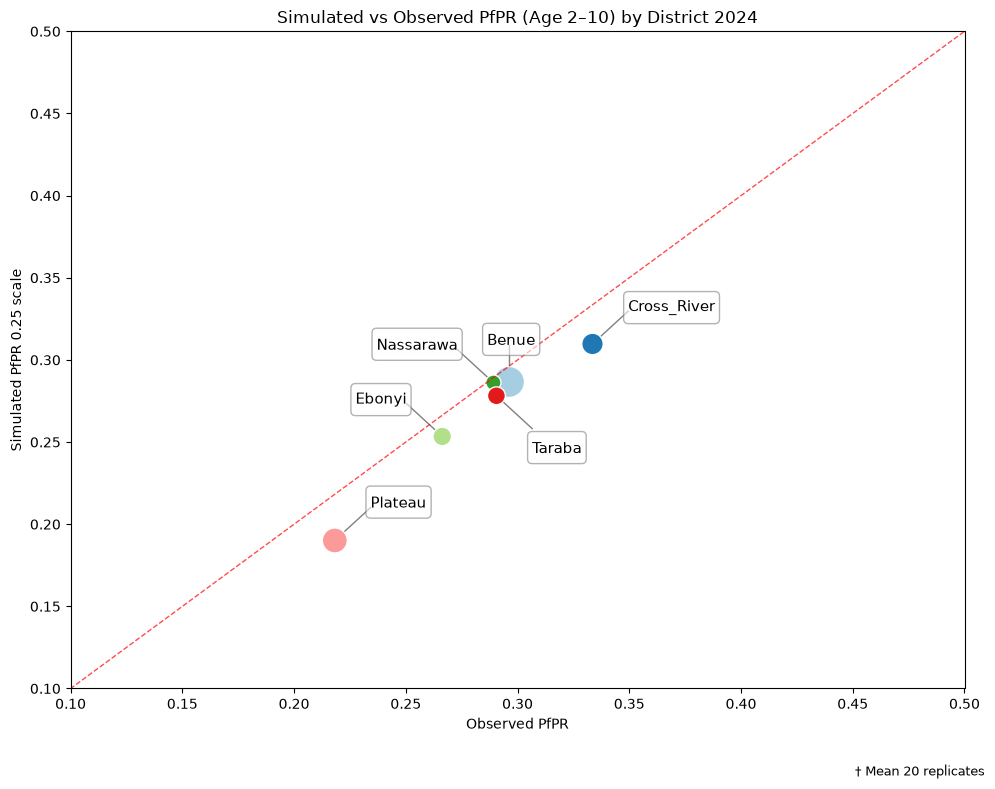

In [45]:
# ======================================================
# Figure 1: Simulated vs Observed PfPR by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d1 = compare_data[["mean_2_to_10_obs", "mean_2_to_10_sim", "State", "mean_population_sim"]].dropna(
    subset=["mean_2_to_10_obs", "mean_2_to_10_sim"]
)

sns.scatterplot(
    data=d1,
    x="mean_2_to_10_obs",
    y="mean_2_to_10_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

''' Use full range when trying to calibrate pipeline, narrow range yields better looking plots when finalized'''

# ax.set_xlim(0.0, 1.0)
# ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.1, 0.5)

span = min(ax.get_xlim()[1] - ax.get_xlim()[0], ax.get_ylim()[1] - ax.get_ylim()[0])

texts = d1["State"].astype(str).fillna("").tolist()
x = d1["mean_2_to_10_obs"].to_numpy(dtype=float)
y = d1["mean_2_to_10_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=11,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.02,
    min_distance=0.10 * span,
    max_distance=0.35 * span,
    nbr_candidates=3000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot([0.0, 1.0], [0.0, 1.0], linestyle="--", linewidth=1, color="red", alpha=0.7)
ax.set_title(f"Simulated vs Observed PfPR (Age 2–10) by District {calibration_year}")
ax.set_xlabel("Observed PfPR")
ax.set_ylabel(f"Simulated PfPR {population_scale_from_input_yml} scale")

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='right', va='bottom', fontsize=9)
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

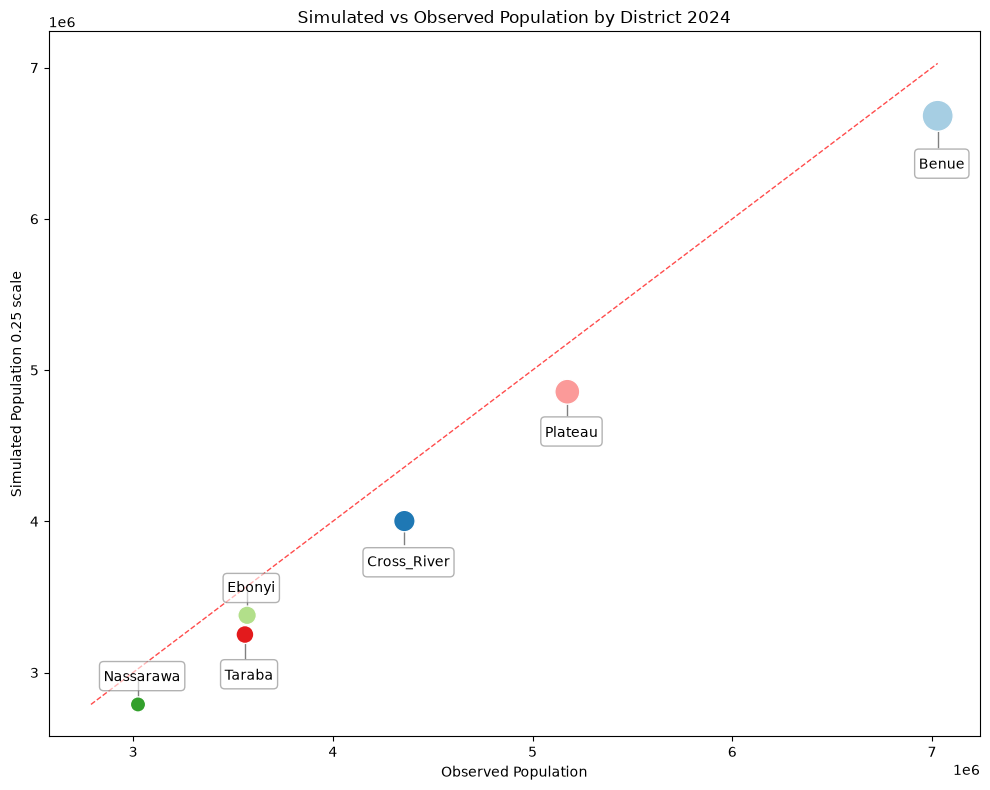

In [46]:
# ======================================================
# Figure 2: Simulated vs Observed Population by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d2 = compare_data[["population_obs", "mean_population_sim", "State"]].dropna(
    subset=["population_obs", "mean_population_sim"]
)

sns.scatterplot(
    data=d2,
    x="population_obs",
    y="mean_population_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

texts = d2["State"].astype(str).fillna("").tolist()
x = d2["population_obs"].to_numpy(dtype=float)
y = d2["mean_population_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=10,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.01,
    min_distance=0.01,
    max_distance=0.08,
    nbr_candidates=300,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

min_val = min(d2["population_obs"].min(), d2["mean_population_sim"].min())
max_val = max(d2["population_obs"].max(), d2["mean_population_sim"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1, color="red", alpha=0.7)

ax.set_title(f"Simulated vs Observed Population by District {calibration_year}")
ax.set_xlabel("Observed Population")
ax.set_ylabel(f"Simulated Population {population_scale_from_input_yml} scale")

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Population_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

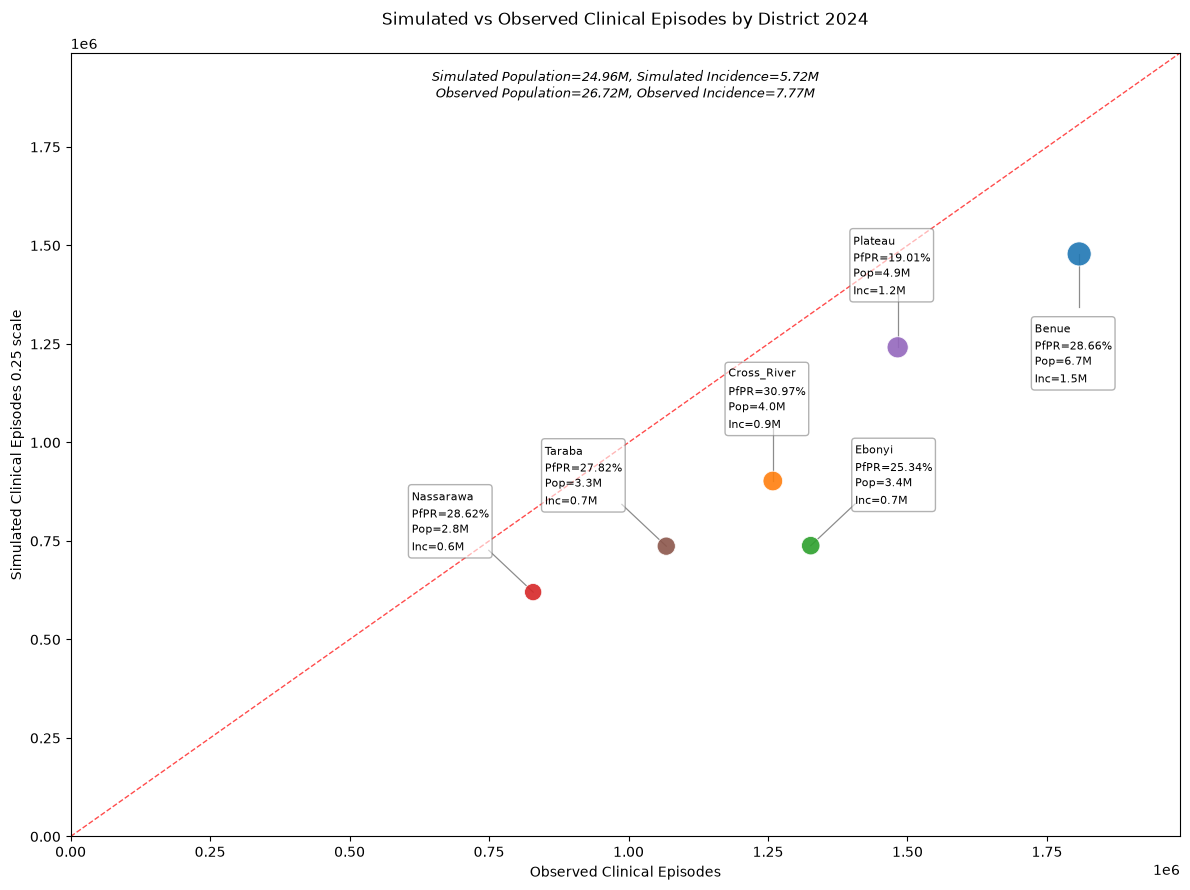

In [47]:
# ======================================================
# Figure 3: Simulated vs Observed Clinical Episodes by District
# ======================================================
fig, ax = plt.subplots(figsize=(12, 9))

d4 = compare_data[
    [
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "State",
        "mean_2_to_10_sim",
        "population_obs"
    ]
].dropna(
    subset=[
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "mean_2_to_10_sim",
        "population_obs"
    ]
).copy()

x = d4["annual_clinical_episodes_obs"].to_numpy(float)
# y = d4["mean_clinical_episodes_sim"].to_numpy(float)
y = d4["adjusted_mean_clinical_episodes_sim"].to_numpy(float)

pop = d4["mean_population_sim"].to_numpy(float)
sizes = (pop / pop.max()) * 250.0 + 50.0

total_pop_sim = d4["mean_population_sim"].sum()
# total_clinical_episodes_sim = d4["mean_clinical_episodes_sim"].sum()
total_clinical_episodes_sim = d4["adjusted_mean_clinical_episodes_sim"].sum()
total_pop_obs = d4["population_obs"].sum()
total_clinical_episodes_obs = d4["annual_clinical_episodes_obs"].sum()

texts = []
for _, row in d4.iterrows():
    name = str(row["State"])
    pfpr = row["mean_2_to_10_sim"]
    population = row["mean_population_sim"]
    # cases = row["mean_clinical_episodes_sim"]
    cases = row["adjusted_mean_clinical_episodes_sim"]
    label = f"{name}\nPfPR={pfpr*100:.2f}%\nPop={population/1e6:.1f}M\nInc={cases/1e6:.1f}M"
    texts.append(label)

districts = d4["State"].astype(str).tolist()
palette = sns.color_palette("tab10", n_colors=len(districts))
color_map = {name: palette[i] for i, name in enumerate(districts)}
colors = [color_map[name] for name in districts]

sc = ax.scatter(
    x, y,
    s=sizes,
    c=colors,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.6,
    zorder=2,
)

maxv = max(np.nanmax(x), np.nanmax(y)) * 1.10
ax.set_xlim(0, maxv)
ax.set_ylim(0, maxv)

linecolor = [(0, 0, 0, 0.45)] * len(x)

allocate(
    ax, x, y, texts,
    scatter_plot=sc,
    textsize=8,
    draw_lines=True,
    draw_all=True,
    linecolor=linecolor,
    linewidth=0.9,
    margin=0.03,
    min_distance=0.04,
    max_distance=0.38,
    nbr_candidates=5000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot(ax.get_xlim(), ax.get_ylim(), color="red", linestyle="--", linewidth=1, zorder=1, alpha=0.7)
ax.set_xlabel("Observed Clinical Episodes")
ax.set_ylabel(f"Simulated Clinical Episodes {population_scale_from_input_yml} scale")
ax.set_title(
    f"Simulated vs Observed Clinical Episodes by District {calibration_year}\n"
)

ax.text(
    0.5, 0.98,
    f"Simulated Population={total_pop_sim/1e6:.2f}M, Simulated Incidence={total_clinical_episodes_sim/1e6:.2f}M\n"
    f"Observed Population={total_pop_obs/1e6:.2f}M, Observed Incidence={total_clinical_episodes_obs/1e6:.2f}M",
    transform=ax.transAxes,
    fontsize=9, color="black", style="italic",
    ha="center", va="top"
)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Clinical_Episodes_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

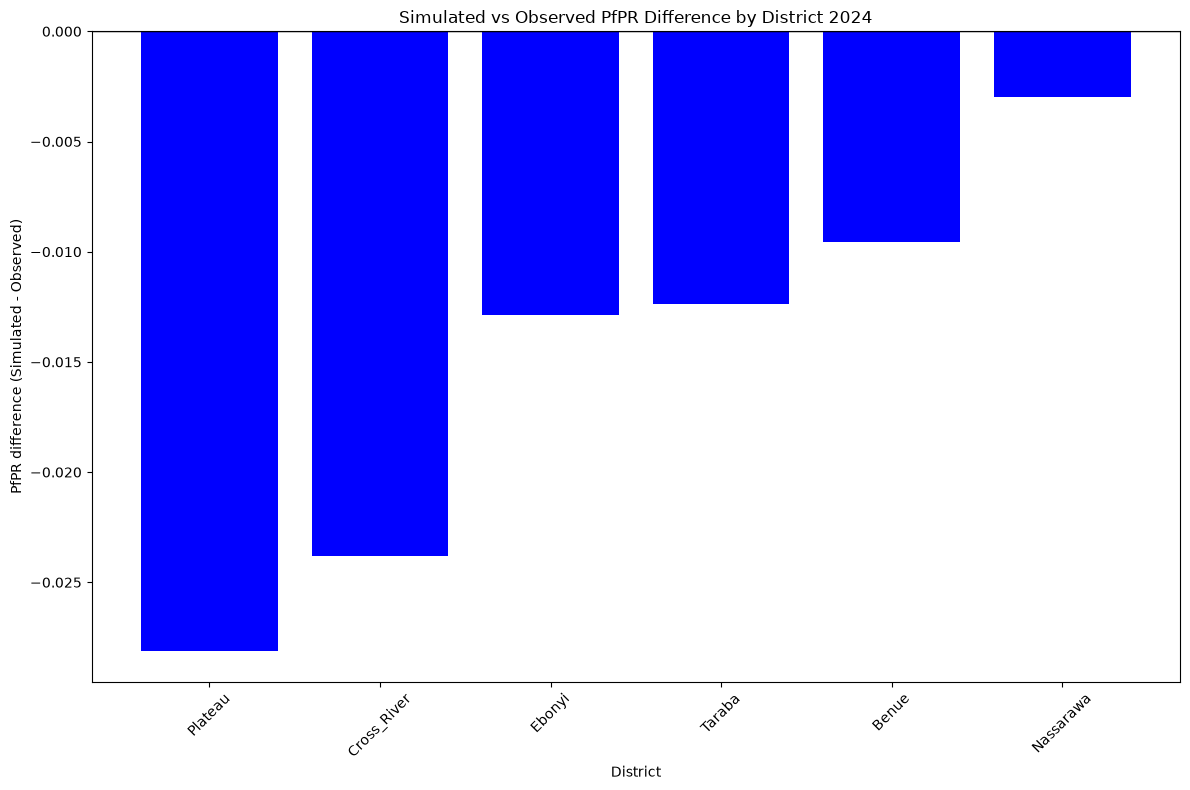

In [48]:
# ======================================================
# Figure 4: Simulated vs Observed PfPR difference by district
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8))

d3 = compare_data.copy()
d3["diff"] = d3["mean_2_to_10_sim"] - d3["mean_2_to_10_obs"]
d3 = d3.sort_values("diff")

colors = ["red" if d > 0 else "blue" for d in d3["diff"]]

ax.bar(d3["State"].astype(str), d3["diff"], color=colors)
ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("District")
ax.set_ylabel("PfPR difference (Simulated - Observed)")
ax.set_title(f"Simulated vs Observed PfPR Difference by District {calibration_year}")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_Difference_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()